In [198]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/RaySilvaP/TelecomX-2/refs/heads/main/TelecomX_2_Data_.csv')
df.drop(['customerID', 'Contas_Diarias', 'gender'], axis=1, inplace=True)

In [199]:
colunas_converter = [
    'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'Churn']

df[colunas_converter] = df[colunas_converter].apply(
    lambda col: col.map({'Yes': 1, 'No': 0})
)

In [200]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

cols_to_encode = [
    "InternetService",
    "Contract",
    "PaymentMethod"
]

encoder_drop = OneHotEncoder(
    handle_unknown = 'ignore',
    drop=['No'],
    sparse_output=False)

encoder_keep = OneHotEncoder(
    handle_unknown = 'ignore',
    sparse_output=False)


one_hot_enc = make_column_transformer(
    (encoder_drop, cols_to_encode[:1]),
    (encoder_keep, cols_to_encode[1:]),
    remainder='passthrough')

df = one_hot_enc.fit_transform(df)
df = pd.DataFrame(df, columns=one_hot_enc.get_feature_names_out())
df.columns = df.columns.str.replace(r"(onehotencoder-\d+__|remainder__)", "", regex=True)

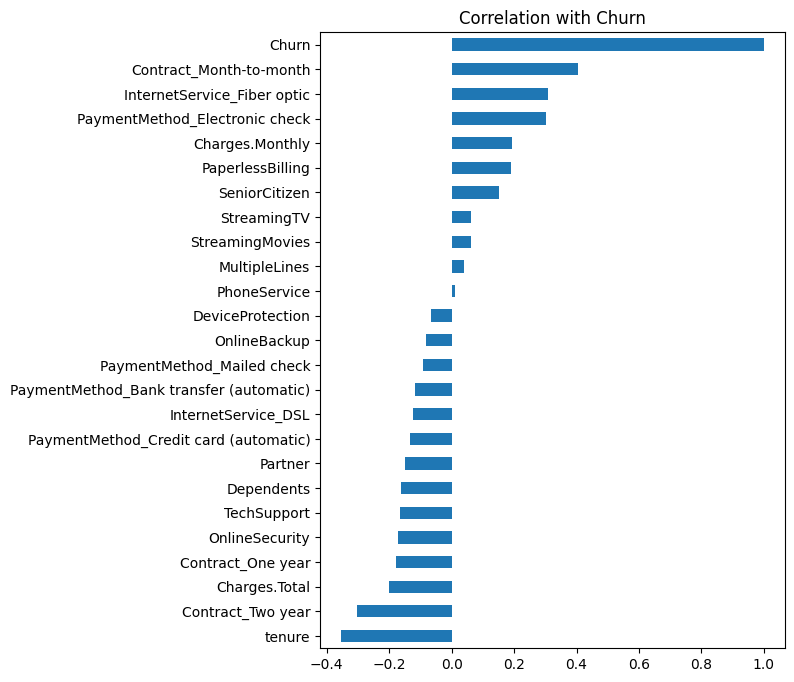

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr()["Churn"].sort_values()

plt.figure(figsize=(6,8))
corr.plot(kind="barh")
plt.title("Correlation with Churn")
plt.show()

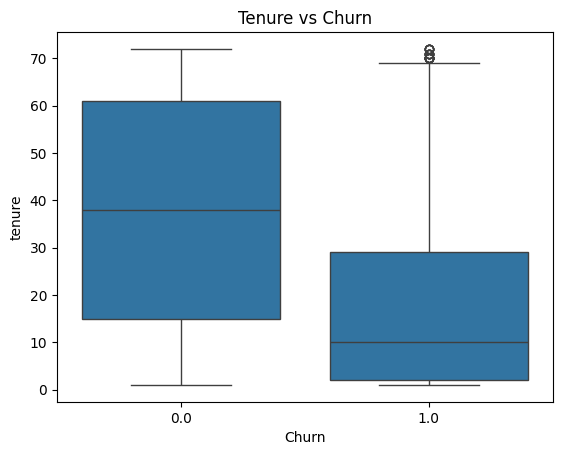

In [202]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.show()

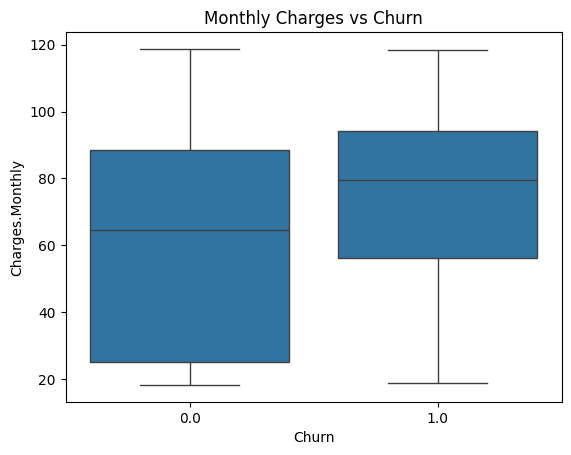

In [203]:
sns.boxplot(x="Churn", y="Charges.Monthly", data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

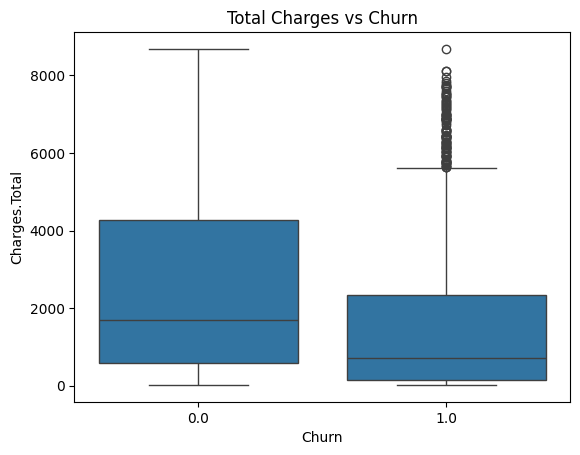

In [204]:
sns.boxplot(x="Churn", y="Charges.Total", data=df)

plt.title("Total Charges vs Churn")
plt.show()

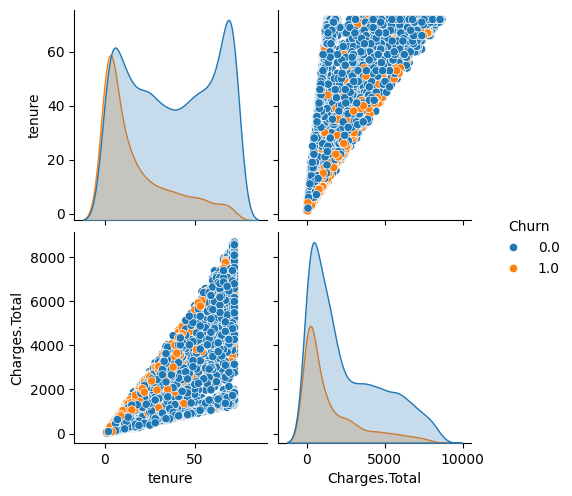

In [205]:
sns.pairplot(
    df[["tenure", "Charges.Total", "Churn"]],
    hue="Churn"
)

In [206]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## **Dummy Classifier**
O Dummy Classifier foi utilizado como modelo de referência inicial (baseline), pois ele realiza previsões simples sem aprender padrões dos dados, geralmente prevendo sempre a classe majoritária. A utilização desse modelo permite estabelecer um nível mínimo de desempenho esperado, servindo como parâmetro para verificar se os modelos mais complexos realmente estão aprendendo informações relevantes do conjunto de dados.

In [207]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)



## **Árvore de Decisão**
A Árvore de Decisão foi selecionada por sua capacidade de capturar relações não lineares entre as variáveis e pela facilidade de interpretação do modelo gerado. Diferentemente de alguns algoritmos lineares, esse método não exige normalização dos dados, pois as decisões são tomadas com base em divisões (splits) nos valores das variáveis. Além disso, árvores de decisão permitem identificar quais atributos possuem maior importância na previsão do churn, auxiliando na compreensão dos fatores que influenciam o comportamento dos clientes.

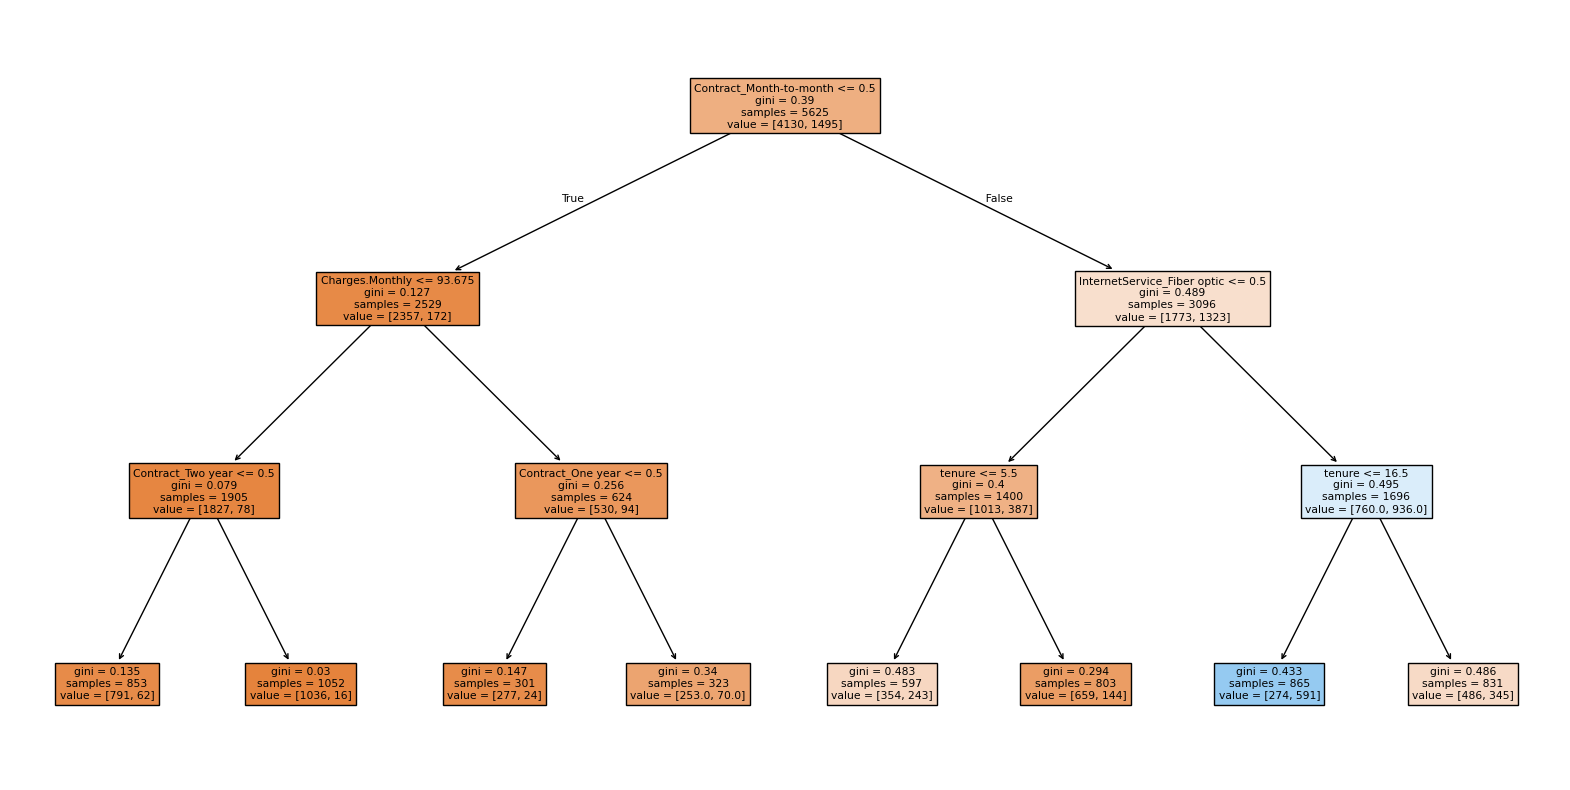

In [208]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=355
)

tree.fit(X_train, y_train)
y_tree_pred = tree.predict(X_test)


plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X_train.columns, filled=True)
plt.show()

## **Regressão Logística**
A Regressão Logística foi escolhida por ser um modelo amplamente utilizado em problemas de classificação binária, como a previsão de churn. Esse modelo possui boa interpretabilidade, permitindo compreender como cada variável influencia na probabilidade de um cliente cancelar o serviço. Para a aplicação da Regressão Logística, é importante realizar a normalização das variáveis numéricas, pois o modelo utiliza métodos de otimização baseados em gradiente. Quando as variáveis possuem escalas muito diferentes, algumas podem dominar o processo de aprendizado, prejudicando a convergência do algoritmo e a qualidade das estimativas dos coeficientes.

In [210]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

num_cols = ["tenure", "Charges.Monthly", "Charges.Total"]
scaler = StandardScaler()

X_train_norm = X_train.copy()
X_train_norm[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test_norm = X_test.copy()
X_test_norm[num_cols] = scaler.transform(X_test[num_cols])

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
)

log_model.fit(X_train_norm, y_train)

y_log_pred = log_model.predict(X_test_norm)


In [213]:
print(f'Dummy:\n {classification_report(y_test, y_dummy_pred)}')
print(f'Logistic Regression:\n {classification_report(y_test, y_log_pred)}')
print(f'Decision Tree:\n {classification_report(y_test, y_tree_pred)}')

Dummy:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85      1033
         1.0       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.90      0.73      0.81      1033
         1.0       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407

Decision Tree:
               precision    recall  f1-score   support

         0.0       0.81      0.94      0.87      1033
         1.0       0.69      0.39      0.50       374

    accuracy                           0.79      1407
   macro avg       0.75      0.66      0.68      1407
weighted avg       0.78     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
